# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the mortality observed in Belgium. In the second part of the project, you try to predict the electricity consumption in Belgium using climate variables.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “Hackathon” on Moodle and the subsection “Remise Hackathon 1”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Mewissen Jean-François, noma : 2748-2400

Part. 2:

Part. 3:

Part. 4:

Part. 5:

Part. 6:

# Mortality and climate

In this section, we analyze the relationship between mortality, age groups, and seasons in Belgium using publicly available data from Statbel (see https://statbel.fgov.be/en/about-statbel/what-we-do/visualisations/mortality). The dataset contains the number of deaths recorded over time, disaggregated by age group and observed across different seasons. The objective is to study temporal patterns in mortality and assess the role of seasonal effects. 

## 1. Basic statistics

**1.1)** Load the dataset mortality_climate.csv. Convert the variables *season* and *CD_AGEGROUP* into a categorical variable. 

In [ ]:
# Utilisation de figure : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_mortality = pd.read_csv("mortality_climate.csv") 
df_mortality['season'] = df_mortality['season'].astype('category')
df_mortality['CD_AGEGROUP'] = df_mortality['CD_AGEGROUP'].astype('category')

print(df_mortality.info())
print("\naperçu de données")
display(df_mortality.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8625 entries, 0 to 8624
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   date          8625 non-null   object  
 1   season        8625 non-null   category
 2   CD_AGEGROUP   8625 non-null   category
 3   MS_NUM_DEATH  8625 non-null   int64   
dtypes: category(2), int64(1), object(1)
memory usage: 152.2+ KB
None

aperçu de données


,date,season,CD_AGEGROUP,MS_NUM_DEATH
0,2022-01-01,winter,25-44,8
1,2022-01-01,winter,45-64,33
2,2022-01-01,winter,65-74,56
3,2022-01-01,winter,75-84,92
4,2022-01-01,winter,85+,141


**1.2)** Plot the evolution of the number of deaths (*MS_NUM_DEATH*) with respect to age group. What do you observe?

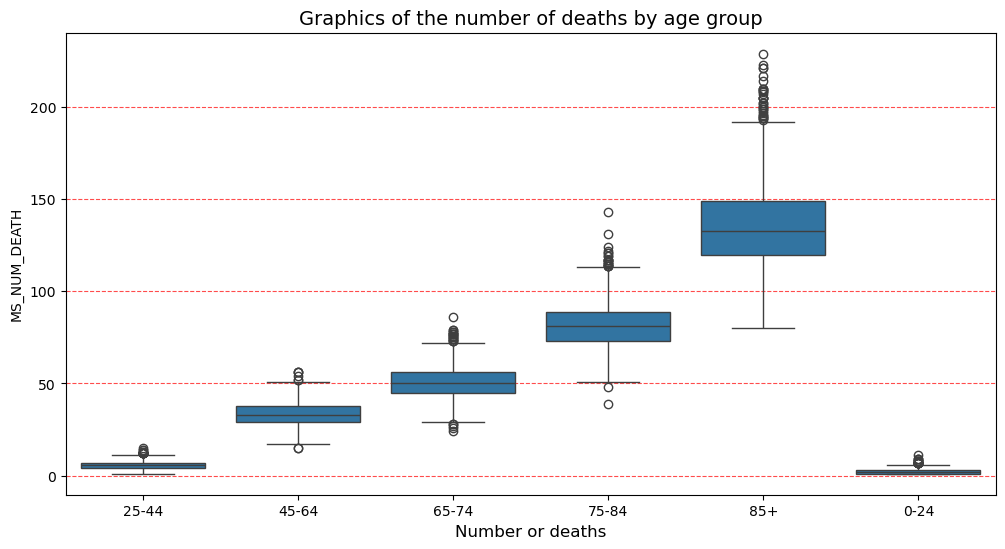

In [ ]:
# Utilisation de boxplot : https://seaborn.pydata.org/generated/seaborn.boxplot.html
# Utilisation de xlabel : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html
# Utilisation de grid : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xlabel.html

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_mortality, x='CD_AGEGROUP', y='MS_NUM_DEATH')

plt.title('Graphics of the number of deaths by age group', fontsize = 14)
plt.xlabel("Age groups", fontsize = 12)
plt.xlabel("Number or deaths", fontsize=12)
plt.grid(color='red', linestyle='--', axis='y', alpha=0.7)
plt.show()


Comments:

Nous pouvons voir que la médiane contenant le plus de décès est celle des personnes ayant plus de 85 ans. Ce qui est logique, au plus nous vieillissons, au plus nous avons de risque de mourir. Et inversément, être plus jeune signifie avoir plus de chance de vivre. Cependant, nous pouvons aussi remarqué certaines valeurs sortent du lot. Bien supérieurs à leur médiane respectives, nous pourrions penser à des données érronées ou qui n'ont que très peu de chance d'arrivé (cas extrême). 

**1.3)** Do a scatter plot of the number of deaths (*MS_NUM_DEATH*) by age group.

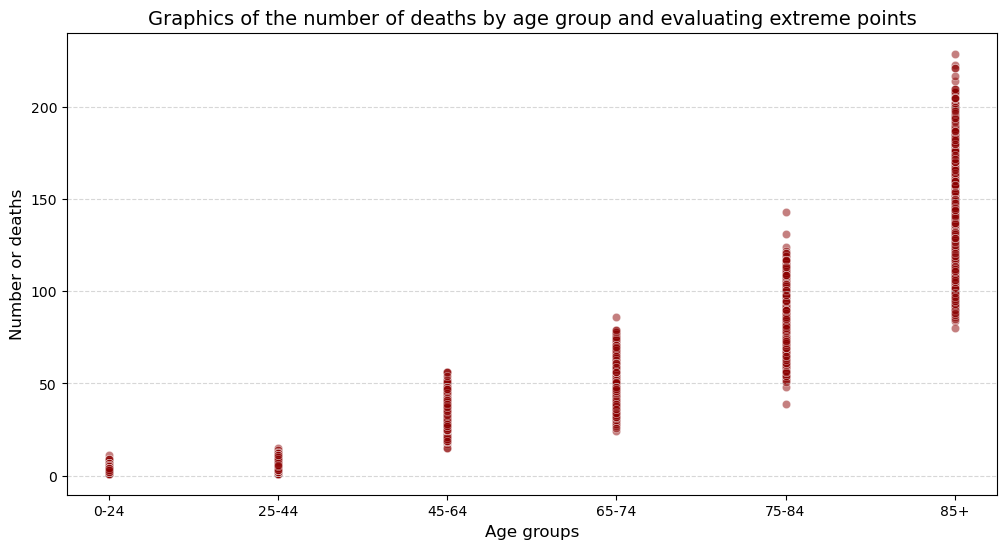

In [ ]:
# Utilisation de plot et scatter : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_mortality, x='CD_AGEGROUP', y='MS_NUM_DEATH', alpha=0.5, color='darkred')

plt.title('Graphics of the number of deaths by age group and evaluating extreme points', fontsize = 14)
plt.xlabel("Age groups", fontsize = 12)
plt.ylabel("Number or deaths", fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

Comments: 

Notre première observation porte sur les intervales du nombre de décès pour chaque tranche d'âge. Au plus la population devient âgée, au plus l'écart du nombre de décès devient important. 

## 2. Fit of distributions

**2.1)** For the 45–64 age group and the winter season only, fit both a Poisson and a Negative Binomial distribution to the variable 'MS_NUM_DEATH' using a maximum likelihood approach. Plot histograms overlaid with the fitted probability mass functions. Compare the log-likelihoods and select the most appropriate distribution.

Log-Likelihood (Poisson) : 15.19
Log-Likelihood (Binomial) : 15.19


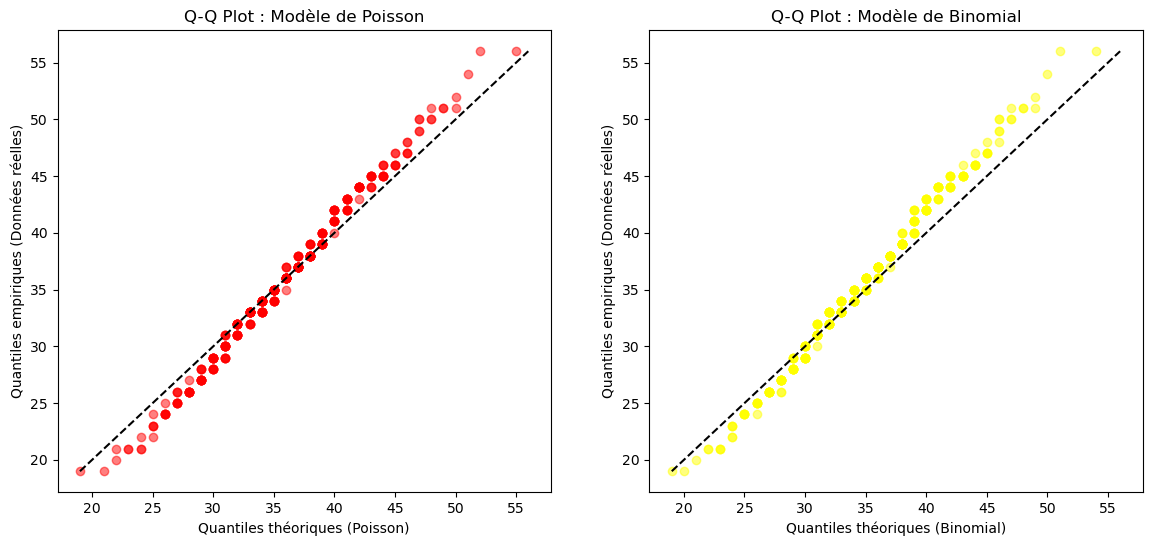

In [ ]:
# Utilisation de dropna() : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
# Algorithme d'optimisation (minimize) : https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
# Utilisation de astype : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html
# Calcul de la variance et de la moyenne : https://numpy.org/doc/stable/reference/generated/numpy.mean.html
# Utilisation de log : https://numpy.org/doc/stable/reference/generated/numpy.log.html
# Utilisation de arange : https://numpy.org/doc/stable/reference/generated/numpy.arange.html


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
from scipy.optimize import minimize

matched = (df_mortality['CD_AGEGROUP'] == '45-64') & (df_mortality['season'].astype(str).str.lower() == 'winter')
filter = df_mortality[matched]
data = (filter['MS_NUM_DEATH'].dropna().values)

lambda_MLE = data.mean()
l_poisson = poisson.pmf(data, lambda_MLE).sum()

def nl_Nbinomial(params) :
    n,p = params
    if (n <= 0 or p <= 0 or p>=1):
        return np.inf 
    return -nbinom.pmf(data, n, p).sum()

mean = data.mean()
var = data.var()
p_init = mean/var if var > mean else 0.5
n_init = p_init*mean / (1-p_init) if var > mean else 10

res = minimize(nl_Nbinomial, [n_init, p_init], method='Nelder-Mead')
n_mle, p_mle = res.x 
l_binom = -res.fun 

print(f"Log-Likelihood (Poisson) : {l_poisson:.2f}")
print(f"Log-Likelihood (Binomial) : {l_binom:.2f}")

sorted_data = np.sort(data)
n_obs = len(data)

quantiles_Obs = (np.arange(1, n_obs+1) - 1/2) / n_obs
Poisson_quantiles = poisson._ppf(quantiles_Obs, lambda_MLE)
Binomial_quantiles = nbinom.ppf(quantiles_Obs, n_mle, p_mle)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_min = np.min([Poisson_quantiles.min(), sorted_data.min(), Binomial_quantiles.min()])
plot_max = np.max([Poisson_quantiles.max(), sorted_data.max(), Binomial_quantiles.max()])

axes[0].scatter(Poisson_quantiles, sorted_data, alpha=0.5, color='red')
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'k--')
axes[0].set_title('Q-Q Plot : Modèle de Poisson')
axes[0].set_xlabel('Quantiles théoriques (Poisson)')
axes[0].set_ylabel('Quantiles empiriques (Données réelles)')

axes[1].scatter(Binomial_quantiles, sorted_data, alpha=0.5, color='yellow')
axes[1].plot([plot_min, plot_max], [plot_min, plot_max], 'k--')
axes[1].set_title('Q-Q Plot : Modèle de Binomial')
axes[1].set_xlabel('Quantiles théoriques (Binomial)')
axes[1].set_ylabel('Quantiles empiriques (Données réelles)')

plt.show()


Comments: 

Nous avons analysons de manière linéaire une relation non-linéaire grâce au passage en logarithmes. 

La loi de Poisson prédit des estimations qui sont au centre assez précises et en adéquations avec le graphique empirique. Cependant, il surestime les quantiles les plus bas (20 à 30) et sous-estime la probabilité des quantiles les élevés de 45 à 55. 

La loi de La Binomiale Négative est relativement précise au centre de son estimation (35-40). Mais surestime le nombre de décès entre les quantiles 20 et 30, et sous-estime ceux entre 45 et 55. 

Laquelle est la plus proche du véritable résultat ? Cela reste encore difficile à déterminer, la loi de Poisson reste imprécises dans ses bornes à l'instar de la loi Binominiale Négative. Il nous faudrait effectuer un test d'hypothèse afin de rendre un verdict plus précis sur la question.  

# 3. Regression

We now aim to assess whether seasonality has an impact on the number of deaths. We consider the following linear model:
$$\log(Y_i) = \beta_0 + \beta_1 X^S_{i1} + \cdots + \beta_3 X^S_{i3} + \beta_4 X^{age}_{i1} + \cdots + \beta_8 X^{age}_{i5}  + \varepsilon_i.$$

where $Y_i$ denotes the number of deaths, $X^S_{ij}$ are dummy variables representing the different seasons, $X^{age}_{ij}$ are dummy variables representing the different age groups, and $\varepsilon_i \sim N(0, \sigma^2)$. 

**3.1)** Why is it more appropriate to use a linear regression on $\log(Y)$ rather than directly on $Y$?

Comments:

Le problème avec Y c'est le fait qu'elle donne un nombre négatif de décès. Le logarithme vient rendre le résultat positif et stabilise l'effet de la variance fluctuant sur les données (au lieu d'avoir des exponentiels, nous avons des additions de logarithmes).


**3.2)** Perform a linear regression of the number of deaths on the seasonal and group age covariates. Use the `OLS` function from the *statsmodels* package. Make sure to convert the variable *season* and *CD_AGEGROUP* into dummy variables before fitting the model.

Does seasonality have a significant impact on mortality? Is the mortality similar for each age group? 

In [ ]:
# Utilisation de statsmodels et OLS : https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html
# Utilisation de get_dummies : https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
# Utilisation de add_constant : https://www.statsmodels.org/stable/generated/statsmodels.tools.tools.add_constant.html

import statsmodels.api as sm
import pandas as pd
import numpy as np

df_reg = df_mortality.dropna(subset=['MS_NUM_DEATH', 'season', 'CD_AGEGROUP']).copy()
df_reg['log_death'] = np.log(df_reg['MS_NUM_DEATH'])

X = pd.get_dummies(df_reg[['season', 'CD_AGEGROUP']], drop_first=True)
X = sm.add_constant(X)
Y = df_reg['log_death']

model = sm.OLS(Y, X.astype(float)).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_death   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 2.110e+04
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        22:36:02   Log-Likelihood:                -2628.0
No. Observations:                8625   AIC:                             5274.
Df Residuals:                    8616   BIC:                             5338.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7921      0.01

Comments:

Oui la saisonnalité a un impact significatif sur les taux de décès. En particulier en hiver où la p-valeur est significativement faible de 0.00 bien inférieur au paramètre alpha de 5% avec un taux de mortalité bien supérieur à l'automne. L'été avec un sa p-valeur négative vient nous informer que c'est la saison où nous avons une baisse significative des décès répertoriés. Le printemps avec une p-valeur de 0.262 est bien supérieur à 5% et n'a donc pas d'impact significatif sur les décès. 

Concernant les tranches d'âges, nous allons analyser les régressions linéaires. La mortalité n'est absolument pas similaires d'un âge à un autre. Toutes les catégories d'âges présentent une p-valeur de 0.00 ce qui implique qu'elles ont un impact très conséquent sur le taux de mortalité. Les coéfficients de régressions augmente drastiquement avec l'âge passant de 0.88 à 4.10 pour les plus de 85 ans. Ce qui confirme l'hypothèse selon laquelle le vieillissement accroît le taux de mortalité. 

## 4. Hypothesis test 

We now investigate whether mortality decreases over time by comparing mortality in summer in 2022 and 2025. To this end, we aim to perform the following hypothesis test:

$$
H_0 : \mu_{2022} = \mu_{2025},
$$

$$
H_1 : \mu_{2022} \neq \mu_{2025}.
$$

**4.1)** Create two subsets of the original dataset corresponding to the years 2022 and 2025, respectively.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Extraction de l'année (to_datetime) : https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html

df_mortality = pd.read_csv("mortality_climate.csv") 
subset1 = df_mortality[pd.to_datetime(df_mortality['date']).dt.year == 2022]
subset2 = df_mortality[pd.to_datetime(df_mortality['date']).dt.year == 2025]


**4.2)** For the 85+ age group, perform a Student’s t-test to compare mortality between 2022 and 2025 **in summer**. Check whether the assumptions required to apply this test are satisfied.

In [ ]:
from scipy.stats import shapiro, bartlett, ttest_ind
# Test de Shapiro-Wilk (shapiro) : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html
# Test de Bartlett (bartlett) : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bartlett.html
# Test de Student (ttest_ind) : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

df_2022 = subset1
df_2025 = subset2

mask_2025 = (df_2025['CD_AGEGROUP']=='85+') & (df_2025['season'].astype(str).str.lower() == 'summer') 
mask_2022 = (df_2022['CD_AGEGROUP']=='85+') & (df_2022['season'].astype(str).str.lower() == 'summer') 

data_2025 = df_2025[mask_2025]['MS_NUM_DEATH'].dropna()
data_2022 = df_2022[mask_2022]['MS_NUM_DEATH'].dropna()

stat_2022, p_22 = shapiro(data_2022)
stat_2025, p_25 = shapiro(data_2025)

stat_bart, p_bart = bartlett(data_2022, data_2025)
t_stat, p_test = ttest_ind(data_2022, data_2025)

print(f"\nRésultat du test de Shapiro 2022 : {p_22:.4f}")
print(f"\nRésultat du test de Shapiro 2025 : {p_25:.4f}")
print(f"\nÉgalité des variances avec Barlett {p_bart:.4f}")
print(f"\nRésultat du test de Student : {p_test:.4f}")



Résultat du test de Shapiro 2022 : 0.0002

Résultat du test de Shapiro 2025 : 0.0000

Égalité des variances avec Barlett 0.0058

Résultat du test de Student : 0.0425


Comments:

**4.3)** Explain what the Wilcoxon test is. Why could it be relevant in our setting?

Comments: 

**4.4)** For the 85+ age group, perform a Wilcoxon test to compare mortality between 2022 and 2025 **in summer**. What do you conclude?

In [22]:
# Code here


Comments:

**4.5)** Perform the Wilcoxon test but now for the 25–44 age group and the **summer**. What do you conclude in this case?

In [23]:
# Code here 


Comments: 

# Electricity Consumption and Climate

In this section, we aim to predict electricity consumption using past consumption values and climatic variables. We rely on data provided by ELIA (see https://opendata.elia.be/explore/dataset/ods003/information/?sort=datetime), which records total electricity consumption in Belgium at a 15-minute frequency, and meteorological data from the Royal Meteorological Institute (IRM) (see https://www.meteo.be/fr/services/donnees), which provides daily average temperature observations over Belgium.

The goal is to build a predictive model for electricity demand based on its recent history and weather conditions. From a practical perspective, such forecasting is highly relevant for energy providers and grid operators, as accurately anticipating electricity demand one week ahead helps optimize production planning, ensure grid stability, and reduce operational costs.

## 5. Forecasting 

The goal is to predict electricity consumption at time $t$ using its past values and climate features. Let $Y_t$ denote electricity consumption at time $t$. We consider the following regression model:

$$Y_t = \beta_0 + \beta_1 Y_{t-7Days} + \beta_2 \bar{T}_{t-7Days} + \beta_3 \bar{T}_{t-7Days}^2 + \varepsilon_t,$$

where $Y_{t-7Days}$ denotes electricity consumption observed 7 days earlier, $\bar{T}_{t-7Days}$ is the average temperature observed 7 days earlier$^1$, and $\varepsilon_t \sim \mathcal{N}(0,\sigma^2)$ is an error term.

$^1$ The average temperature is measured at a daily frequency; therefore, $\bar{T}_{t-7Days}$ is constant for all time points $t$ within the same day.

**5.1)** Load the dataset *electricity_climate.csv* and construct the dataset required to perform the regression.

**Warning:** the data are observed at 15-minute intervals.

To build the regression dataset, each row must contain:
- electricity consumption at time $t$: $Y_t$,
- electricity consumption at time $t - 7$ days: $Y_{t-7Days}$,
- temperature at time $t - 7$ days: $\bar{T}_{t-7Days}$,
- the squared temperature at time $t - 7$ days: $\bar{T}_{t-7Days}^2$.

**5.2)** Split the dataset into a training set (first 75%) and a test set (last 25%).  Use the `OLS` function from the *statsmodels* package to fit linear regression model using only $Y_{t-7Days}$ as explanatory variable.

Analyze the regression output, discuss the statistical significance and performance of the model.

In [24]:
# Code here 


Comments:

**5.3)** Repeat the regression by including the climate variables in the model.

Are the climate variables statistically significant in explaining electricity consumption 7 days ahead?

In [25]:
# Code here


Comments: 

**5.4)** Compute the MAE and RMSE on the test set for both models: with and without climate variables.

Does the inclusion of climate variables improve the predictive performance of the model?

In [26]:
# Code here 


Comments: 

**5.5)** For the model including climate variables, plot the predicted electricity consumption versus the true consumption on the test set. Then, produce a second plot focusing only on the first 7 days of the test set.

In [27]:
# Code here 


Comments: